# Parameter Estimation: Series Reaction A → B → C

This notebook demonstrates GMM and Flow Matching approaches for parameter estimation as an inverse problem.

**Problem:** Given observed exit molar flows from a plug flow reactor, estimate the rate constants k₁ and k₂.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 10:15:02
Initial memory usage: 317.86 MB


## System Information

This section documents the computational environment used to run this notebook.

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch
from scipy.integrate import solve_ivp
from scipy.interpolate import griddata

# Import reusable utilities
from generative_optimization import (
    generate_samples,
    best_gmm,
    ConditionalFlowMatching,
    cluster_stats
)

# Figure settings for publication
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10

warnings.filterwarnings('ignore')

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete")

Setup complete


---
## Problem: Parameter Estimation for Series Reactions

Consider series reactions in a plug flow reactor (PFR):
$$A \xrightarrow{k_1} B \xrightarrow{k_2} C$$

**Reactor model:**
$$\frac{dF_A}{dV} = -\frac{k_1 F_A}{\nu}, \quad \frac{dF_B}{dV} = \frac{k_1 F_A}{\nu} - \frac{k_2 F_B}{\nu}$$

**Forward problem:** Given $(k_1, k_2)$ → compute $(F_A, F_B)$ at reactor exit

**Inverse problem:** Given observed $(F_A, F_B)$ → estimate $(k_1, k_2)$

**Reactor parameters:**
- Volumetric flow rate: $\nu = 1$ L/s
- Reactor volume: $V_f = 2$ L
- Inlet flows: $F_{A0} = 1$ mol/s, $F_{B0} = 0$ mol/s

In [3]:
# Reactor parameters
nu = 1   # volumetric flow rate (L/s)
Vf = 2   # reactor volume (L)
F0 = [1, 0]  # inlet molar flows [Fa0, Fb0] (mol/s)

def ode(V, F, k1, k2):
    """ODE system for series reaction A -> B -> C"""
    Fa, Fb = F
    dFadV = -k1 * Fa / nu
    dFbdV = k1 * Fa / nu - k2 * Fb / nu
    return dFadV, dFbdV

# Test the forward model
k_test = [1.5, 2.0]
sol = solve_ivp(ode, t_span=(0, Vf), y0=F0, args=tuple(k_test))
Fa_exit, Fb_exit = sol.y[:, -1]

print(f"Test forward model: k1={k_test[0]}, k2={k_test[1]}")
print(f"  Exit flows: Fa={Fa_exit:.4f}, Fb={Fb_exit:.4f}")

Test forward model: k1=1.5, k2=2.0
  Exit flows: Fa=0.0498, Fb=0.0944


### Generate Training Data

In [4]:
# Generate data: sample rate constants and compute exit flows
bounds = [[0.1, 3], [0.1, 3]]
K = generate_samples(bounds, n_samples=256, seed=42)

data = []
for k1, k2 in K:
    sol = solve_ivp(ode, t_span=(0, Vf), y0=F0, args=(k1, k2))
    Fa, Fb = sol.y[:, -1]
    data.append([k1, k2, Fa, Fb])

data = np.array(data)
print(f"Training data shape: {data.shape}")
print(f"Columns: [k1, k2, Fa_exit, Fb_exit]")
print(f"\nk1 range: [{data[:, 0].min():.2f}, {data[:, 0].max():.2f}]")
print(f"k2 range: [{data[:, 1].min():.2f}, {data[:, 1].max():.2f}]")
print(f"Fa range: [{data[:, 2].min():.4f}, {data[:, 2].max():.4f}]")
print(f"Fb range: [{data[:, 3].min():.4f}, {data[:, 3].max():.4f}]")

Training data shape: (256, 4)
Columns: [k1, k2, Fa_exit, Fb_exit]

k1 range: [0.10, 2.99]
k2 range: [0.11, 2.99]
Fa range: [0.0025, 0.8130]
Fb range: [0.0159, 0.8129]


### Train GMM for Parameter Estimation

In [5]:
# Build GMM on joint distribution [k1, k2, Fa, Fb]
gmm, gmm_info = best_gmm(data, verbose=True)
print(f"\nBest GMM: {gmm_info['best_k']} components")

k=1: BIC=439.6 *
k=2: BIC=-465.0 *
k=3: BIC=-886.7 *
k=4: BIC=-1149.4 *
k=5: BIC=-1308.4 *
k=6: BIC=-1502.1 *
k=7: BIC=-1544.6 *
k=8: BIC=-1618.2 *
k=9: BIC=-1669.4 *
k=10: BIC=-1702.4 *
k=11: BIC=-1765.5 *


k=12: BIC=-1718.8

Best GMM: 11 components


### Investigate GMM Structure and Satellite Peaks

Before using the GMM for prediction, let's examine its structure to understand potential multimodality.

GMM has 11 components

Component weights (priors):
  Component 1: 0.0792
  Component 2: 0.0962
  Component 3: 0.1017
  Component 4: 0.1033
  Component 5: 0.0864
  Component 6: 0.1247
  Component 7: 0.0860
  Component 8: 0.0619
  Component 9: 0.0832
  Component 10: 0.1209
  Component 11: 0.0566

Component means for (k1, k2):
  Component 1: k1=1.157, k2=0.527
  Component 2: k1=1.577, k2=2.357
  Component 3: k1=0.277, k2=1.940
  Component 4: k1=2.573, k2=0.595
  Component 5: k1=0.780, k2=1.507
  Component 6: k1=2.437, k2=1.584
  Component 7: k1=0.897, k2=2.479
  Component 8: k1=0.499, k2=0.537
  Component 9: k1=1.571, k2=1.328
  Component 10: k1=2.473, k2=2.559
  Component 11: k1=1.835, k2=0.512


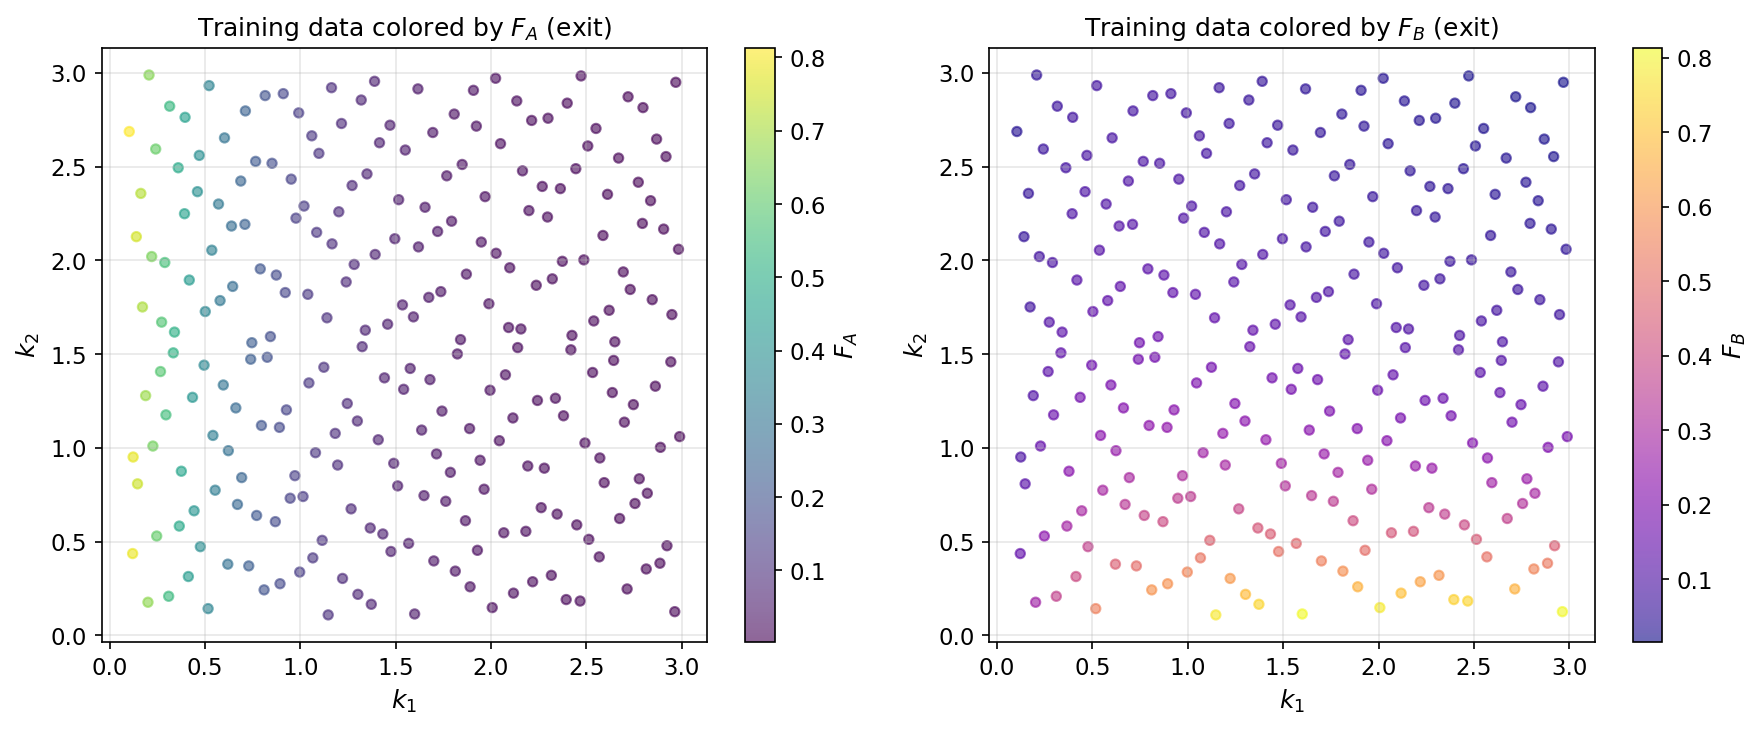

In [6]:
# Examine GMM structure
print(f"GMM has {len(gmm.priors)} components")
print(f"\nComponent weights (priors):")
for i, prior in enumerate(gmm.priors):
    print(f"  Component {i+1}: {prior:.4f}")

# Check the means in the (k1, k2) space (first 2 dimensions)
print(f"\nComponent means for (k1, k2):")
for i, mean in enumerate(gmm.means):
    print(f"  Component {i+1}: k1={mean[0]:.3f}, k2={mean[1]:.3f}")

# Visualize the training data in (k1, k2) space colored by (Fa, Fb)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Color by Fa
sc1 = axes[0].scatter(data[:, 0], data[:, 1], c=data[:, 2], s=20, alpha=0.6, cmap='viridis')
axes[0].set_xlabel('$k_1$')
axes[0].set_ylabel('$k_2$')
axes[0].set_title('Training data colored by $F_A$ (exit)')
plt.colorbar(sc1, ax=axes[0], label='$F_A$')
axes[0].grid(True, alpha=0.3)

# Right: Color by Fb
sc2 = axes[1].scatter(data[:, 0], data[:, 1], c=data[:, 3], s=20, alpha=0.6, cmap='plasma')
axes[1].set_xlabel('$k_1$')
axes[1].set_ylabel('$k_2$')
axes[1].set_title('Training data colored by $F_B$ (exit)')
plt.colorbar(sc2, ax=axes[1], label='$F_B$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Diagnosis: Sources of Satellite Peaks

The satellite peak in the GMM distribution can arise from several sources:

**1. Non-unique inverse problem:**
   - Multiple (k₁, k₂) combinations can produce similar exit flows
   - The mapping from observations → parameters is not perfectly one-to-one
   
**2. GMM structure:**
   - The GMM uses 11 components (selected by BIC)
   - When conditioning on specific (Fa, Fb) values, multiple components may contribute
   - Components with different (k₁, k₂) centers but similar (Fa, Fb) projections create multimodality

**3. Sparse training data:**
   - Only 256 training samples across a 2D parameter space
   - Regions between training points rely on GMM interpolation
   - The GMM may create artificial modes to fit gaps in the data

**4. Physical insights:**
   - For very low Fa and Fb, both reactions must be fast
   - Small variations in observations near the boundary can map to larger variations in parameters
   - This creates inherent uncertainty in the inverse problem

**Recommendations:**
1. **More training data:** Increase sampling density, especially near regions of interest
2. **Regularization:** Consider penalizing excessive multimodality or using fewer GMM components
3. **Physical constraints:** Add bounds on k₁ and k₂ based on domain knowledge
4. **Interpretation:** The satellite peak represents genuine uncertainty - multiple parameter sets are consistent with the observations within measurement/model error

### Train Flow Matching for Parameter Estimation

In [7]:
# Train Flow Matching: generate [k1, k2] conditioned on [Fa, Fb]
x_data = data[:, :2]  # k1, k2
c_data = data[:, 2:]  # Fa, Fb

fm_param = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=64, n_layers=3)
fm_history = fm_param.fit(x_data, c_data, epochs=500, batch_size=64, verbose=True)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

### Parameter Estimation for Test Cases

In [8]:
# Define two test scenarios
observations = np.array([
    [0.02, 0.05],   # Scenario 1: low Fa, low Fb (both reactions fast)
    [0.02, 0.65]    # Scenario 2: low Fa, high Fb (reaction 2 slow)
])

print("Parameter Estimation Test Cases")
print("=" * 70)

# GMM estimation
print("\nGMM Estimates:")
k_gmm = gmm.predict([2, 3], observations)
for i, (obs, params) in enumerate(zip(observations, k_gmm)):
    k1, k2 = params
    Fa_exit, Fb_exit = solve_ivp(ode, t_span=(0, Vf), y0=F0, 
                                  args=(k1, k2)).y[:, -1]
    print(f"  Scenario {i+1}: Target Fa={obs[0]:.3f}, Fb={obs[1]:.3f}")
    print(f"    Estimated k1={k1:.3f}, k2={k2:.3f}")
    print(f"    Validation: Fa={Fa_exit:.3f}, Fb={Fb_exit:.3f}")

# Flow Matching estimation
print("\nFlow Matching Estimates:")
k_fm = []
for i, obs in enumerate(observations):
    samples = fm_param.sample(c_values=[obs.tolist()], n_samples=500)
    k_est = samples.mean(axis=0)
    k_fm.append(k_est)
    
    Fa_exit, Fb_exit = solve_ivp(ode, t_span=(0, Vf), y0=F0, 
                                  args=(k_est[0], k_est[1])).y[:, -1]
    print(f"  Scenario {i+1}: Target Fa={obs[0]:.3f}, Fb={obs[1]:.3f}")
    print(f"    Estimated k1={k_est[0]:.3f}, k2={k_est[1]:.3f}")
    print(f"    Validation: Fa={Fa_exit:.3f}, Fb={Fb_exit:.3f}")

k_fm = np.array(k_fm)

Parameter Estimation Test Cases

GMM Estimates:
  Scenario 1: Target Fa=0.020, Fb=0.050
    Estimated k1=1.857, k2=2.480
    Validation: Fa=0.024, Fb=0.052
  Scenario 2: Target Fa=0.020, Fb=0.650
    Estimated k1=1.946, k2=0.287
    Validation: Fa=0.020, Fb=0.636

Flow Matching Estimates:
  Scenario 1: Target Fa=0.020, Fb=0.050
    Estimated k1=1.939, k2=2.460
    Validation: Fa=0.021, Fb=0.050
  Scenario 2: Target Fa=0.020, Fb=0.650
    Estimated k1=2.001, k2=0.278
    Validation: Fa=0.018, Fb=0.644


---
## Publication Figure: GMM vs Flow Matching Comparison

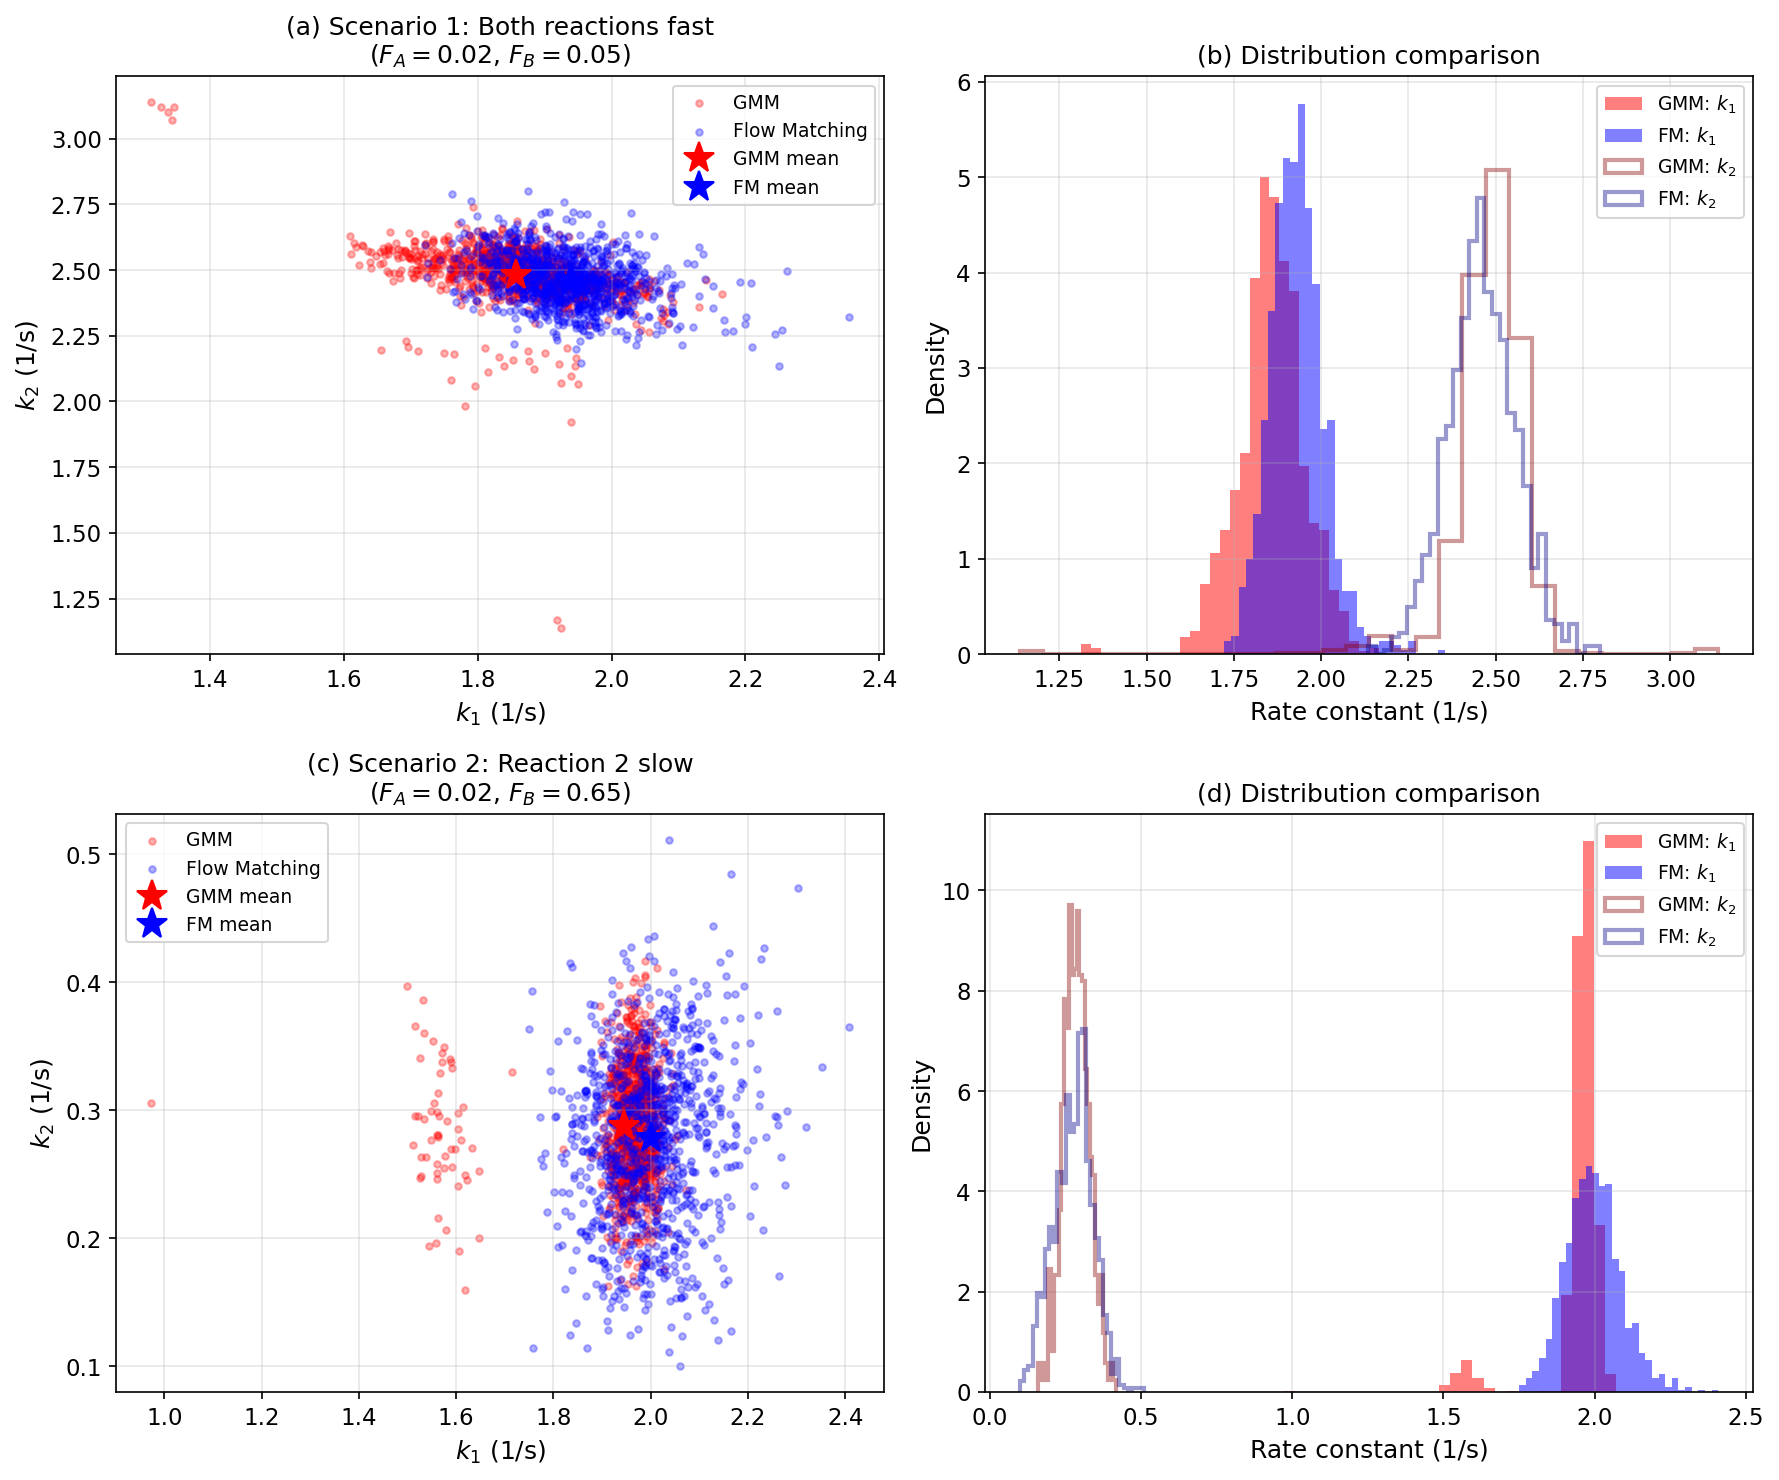


Figure saved as 'parameter_estimation_comparison.png'


In [9]:
# Create publication figure: 2x2 grid
# Top row: Uncertainty distributions for Scenario 1
# Bottom row: Uncertainty distributions for Scenario 2

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

scenario_labels = [
    "Scenario 1: Both reactions fast\n($F_A=0.02$, $F_B=0.05$)",
    "Scenario 2: Reaction 2 slow\n($F_A=0.02$, $F_B=0.65$)"
]

for row, (obs, k_g, k_f) in enumerate(zip(observations, k_gmm, k_fm)):
    # Sample from GMM
    c_gmm = gmm.condition([2, 3], [obs])
    samples_gmm = c_gmm.sample(1000)
    
    # Sample from Flow Matching
    samples_fm = fm_param.sample(c_values=[obs.tolist()], n_samples=1000)
    
    # Left column: k1 vs k2 scatter
    ax = axes[row, 0]
    ax.scatter(samples_gmm[:, 0], samples_gmm[:, 1], alpha=0.3, s=10, 
               color='red', label='GMM')
    ax.scatter(samples_fm[:, 0], samples_fm[:, 1], alpha=0.3, s=10, 
               color='blue', label='Flow Matching')
    ax.plot(k_g[0], k_g[1], 'r*', ms=15, label='GMM mean')
    ax.plot(k_f[0], k_f[1], 'b*', ms=15, label='FM mean')
    ax.set_xlabel('$k_1$ (1/s)')
    ax.set_ylabel('$k_2$ (1/s)')
    ax.set_title(f'({chr(97+row*2)}) {scenario_labels[row]}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Right column: Overlapping histograms for k1 and k2
    ax = axes[row, 1]
    
    # k1 histograms
    ax.hist(samples_gmm[:, 0], bins=30, alpha=0.5, color='red', 
            label='GMM: $k_1$', density=True)
    ax.hist(samples_fm[:, 0], bins=30, alpha=0.5, color='blue', 
            label='FM: $k_1$', density=True)
    
    # k2 histograms (with different style)
    ax.hist(samples_gmm[:, 1], bins=30, alpha=0.4, color='darkred', 
            label='GMM: $k_2$', density=True, histtype='step', linewidth=2)
    ax.hist(samples_fm[:, 1], bins=30, alpha=0.4, color='darkblue', 
            label='FM: $k_2$', density=True, histtype='step', linewidth=2)
    
    ax.set_xlabel('Rate constant (1/s)')
    ax.set_ylabel('Density')
    ax.set_title(f'({chr(98+row*2)}) Distribution comparison')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parameter_estimation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'parameter_estimation_comparison.png'")

### Quantitative Comparison

In [10]:
print("Parameter Estimation: Quantitative Comparison")
print("=" * 80)

for i, obs in enumerate(observations):
    print(f"\nScenario {i+1}: Observed Fa={obs[0]:.3f}, Fb={obs[1]:.3f}")
    print("-" * 80)
    
    # GMM statistics
    c_gmm = gmm.condition([2, 3], [obs])
    samples_gmm = c_gmm.sample(1000)
    k1_gmm_mean, k2_gmm_mean = samples_gmm.mean(axis=0)
    k1_gmm_std, k2_gmm_std = samples_gmm.std(axis=0)
    
    # Flow Matching statistics
    samples_fm = fm_param.sample(c_values=[obs.tolist()], n_samples=1000)
    k1_fm_mean, k2_fm_mean = samples_fm.mean(axis=0)
    k1_fm_std, k2_fm_std = samples_fm.std(axis=0)
    
    print(f"{'Method':<20} {'k1 (mean ± std)':<25} {'k2 (mean ± std)':<25}")
    print(f"{'GMM':<20} {k1_gmm_mean:.3f} ± {k1_gmm_std:.3f}             {k2_gmm_mean:.3f} ± {k2_gmm_std:.3f}")
    print(f"{'Flow Matching':<20} {k1_fm_mean:.3f} ± {k1_fm_std:.3f}             {k2_fm_mean:.3f} ± {k2_fm_std:.3f}")
    
    # Validation: compute exit flows using estimated parameters
    Fa_gmm, Fb_gmm = solve_ivp(ode, t_span=(0, Vf), y0=F0, 
                                args=(k1_gmm_mean, k2_gmm_mean)).y[:, -1]
    Fa_fm, Fb_fm = solve_ivp(ode, t_span=(0, Vf), y0=F0, 
                              args=(k1_fm_mean, k2_fm_mean)).y[:, -1]
    
    print(f"\nValidation (predicted exit flows):")
    print(f"  Target:        Fa={obs[0]:.4f}, Fb={obs[1]:.4f}")
    print(f"  GMM:           Fa={Fa_gmm:.4f}, Fb={Fb_gmm:.4f}")
    print(f"  Flow Matching: Fa={Fa_fm:.4f}, Fb={Fb_fm:.4f}")
    
    # Errors
    err_gmm = np.sqrt((Fa_gmm - obs[0])**2 + (Fb_gmm - obs[1])**2)
    err_fm = np.sqrt((Fa_fm - obs[0])**2 + (Fb_fm - obs[1])**2)
    print(f"\nRMSE:")
    print(f"  GMM:           {err_gmm:.6f}")
    print(f"  Flow Matching: {err_fm:.6f}")

Parameter Estimation: Quantitative Comparison

Scenario 1: Observed Fa=0.020, Fb=0.050
--------------------------------------------------------------------------------
Method               k1 (mean ± std)           k2 (mean ± std)          
GMM                  1.855 ± 0.107             2.478 ± 0.135
Flow Matching        1.933 ± 0.079             2.463 ± 0.097

Validation (predicted exit flows):
  Target:        Fa=0.0200, Fb=0.0500
  GMM:           Fa=0.0245, Fb=0.0519
  Flow Matching: Fa=0.0209, Fb=0.0499

RMSE:
  GMM:           0.004881
  Flow Matching: 0.000954

Scenario 2: Observed Fa=0.020, Fb=0.650
--------------------------------------------------------------------------------
Method               k1 (mean ± std)           k2 (mean ± std)          
GMM                  1.951 ± 0.078             0.286 ± 0.045
Flow Matching        1.997 ± 0.094             0.277 ± 0.063

Validation (predicted exit flows):
  Target:        Fa=0.0200, Fb=0.6500
  GMM:           Fa=0.0202, Fb=0.6373

### Summary: Parameter Estimation

Both GMM and Flow Matching successfully solve the inverse problem of estimating rate constants from observed reactor exit flows.

**Key observations:**

1. **Scenario 1 (both reactions fast):** Both $k_1$ and $k_2$ are large, leading to low exit flows for both A and B. Both methods accurately estimate the parameters with narrow uncertainty distributions.

2. **Scenario 2 (reaction 2 slow):** Large $k_1$ (fast) and small $k_2$ (slow) leads to low $F_A$ but high $F_B$ at the exit. Both methods correctly identify this pattern.

3. **Uncertainty quantification:** The generative approach naturally provides uncertainty estimates through sampling. The scatter plots show the joint distribution of $(k_1, k_2)$, revealing correlations between parameters.

4. **Validation:** The estimated parameters accurately reproduce the observed exit flows when used in the forward model, confirming the quality of the estimates.

**Limitations:**
- Both methods require interpolation within the training data range
- Extrapolation to observations outside the training range can produce unreliable results
- The narrow distributions can give false confidence for out-of-distribution queries

In [11]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 10:15:02
End time:        2025-12-18 10:15:06
Elapsed time:    4.40 seconds (0.07 minutes)
----------------------------------------------------------------------
Initial memory:  317.86 MB
Final memory:    552.33 MB
Memory change:   +234.47 MB


In [12]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 10:15:02
End time:        2025-12-18 10:15:06
Elapsed time:    4.41 seconds (0.07 minutes)
----------------------------------------------------------------------
Initial memory:  317.86 MB
Final memory:    552.33 MB
Memory change:   +234.47 MB
